In [1]:
import os 
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch
import csv, random
import time
import pandas as pd
import itertools
from pathlib import Path

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [3]:
def load_png_as_rgb(png_path):
    with Image.open(png_path) as img:
        img = img.convert("RGB")
        arr = np.array(img, dtype = np.uint8)

    assert arr.ndim == 3 and arr.shape[2] == 3
    assert arr.dtype == np.uint8
    return arr

def show_anns(anns, borders=True):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:, :, 3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.5]])
        img[m] = color_mask 
        if borders:
            import cv2
            contours, _ = cv2.findContours(m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE) 
            # Try to smooth contours
            contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
            cv2.drawContours(img, contours, -1, (0, 0, 1, 0.4), thickness=1) 

    ax.imshow(img)

def iou_binary(pred_bool, gt_bool):
    inter = np.logical_and(pred_bool, gt_bool).sum()
    uni   = np.logical_or(pred_bool, gt_bool).sum()
    return inter / uni if uni > 0 else float("nan")

In [4]:
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

In [5]:
sam2_checkpoint = str(Path(os.environ.get("SAM2_CHECKPOINT", "../checkpoints/sam2.1_hiera_large.pt")))
model_cfg = str(Path("configs/sam2.1/sam2.1_hiera_l.yaml"))

In [6]:
sam2 = build_sam2(model_cfg, sam2_checkpoint, device=device, apply_postprocessing=False)

In [7]:
paired_csv = Path.home() / "skimage_segmentation" / "paired.csv"

with paired_csv.open(newline="", encoding="utf-8") as f:
    rows = list(csv.DictReader(f))

idxs = sorted(random.sample(range(len(rows)), k=min(10, len(rows))))
idxs

[17, 30, 51, 55, 56, 63, 75, 77, 78, 84]

In [8]:
i = idxs[4]

stem = rows[i]["stem"]

print(stem)

png_path = rows[i]["png_path"].strip()
npz_path = rows[i]["npz_path"].strip()

image = load_png_as_rgb(png_path)


data = np.load(npz_path)
ice_mask = data["ice_mask"]          
labels = data["labels"]  

print("ice_mask unique:", np.unique(ice_mask))
print("ice pixels:", (~ice_mask).sum())
print("water pixels:", ice_mask.sum())

S1A_EW_GRDM_1SDH_20200101T074515_20200101T074619_030604_038191_EBD1.SAFE_6_2
ice_mask unique: [False  True]
ice pixels: 116190
water pixels: 145954


/home/predm/sam2/sam2/sam2_image_predictor.py:431: UserWarning: cannot import name '_C' from 'sam2' (/home/predm/sam2/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  masks = self._transforms.postprocess_masks(


masks: 28
keys: dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])
generate time: 43.532375280999986
pred_iou: min 0.7354967594146729 mean 0.8676135625158038 max 0.9884236454963684
stability: min 0.9207459092140198 mean 0.9381450010197503 max 0.9750000238418579


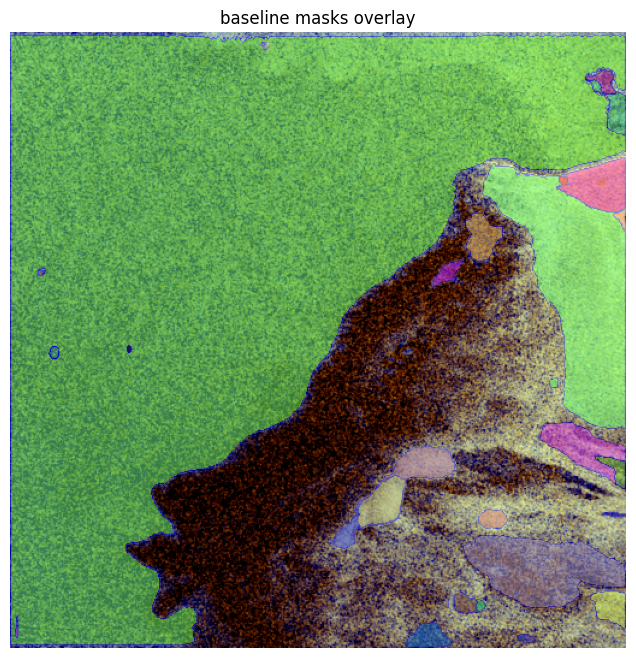


baseline coverage: 0.671783447265625
baseline union coverage: 0.671783447265625
Pred water: 146059
Pred ice: 30045
Unclassified: 86040

IoU water (covered): 0.9752661304124594
IoU water (full):    0.9525981103436286
IoU ice (covered):   0.892604482492123
IoU ice (full):      0.2584117859663012


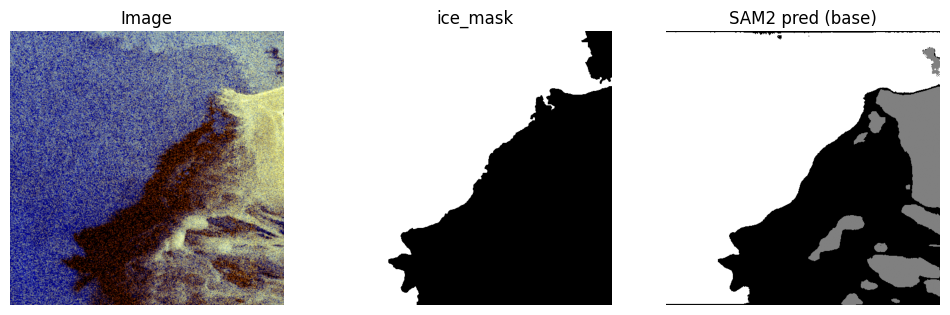

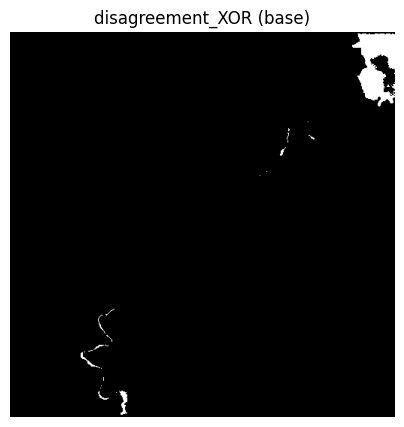

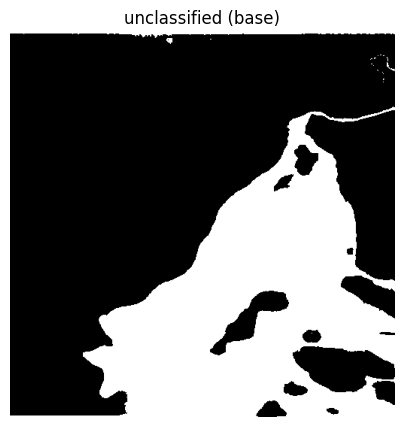

In [9]:
base_cfg = dict(
    points_per_side=64,
    points_per_batch=128,
    pred_iou_thresh=0.6,
    stability_score_thresh=0.92,
    stability_score_offset=0.6,
    crop_n_layers=1,
    box_nms_thresh=0.8,
    crop_n_points_downscale_factor=2,
    min_mask_region_area=50.0,
    use_m2m=True,
)

mask_generator_2 = SAM2AutomaticMaskGenerator(model=sam2, **base_cfg)

t0 = time.perf_counter()
masks = mask_generator_2.generate(image)
t_generate = time.perf_counter() - t0


print("masks:", len(masks))
if len(masks) > 0:
    print("keys:", masks[0].keys())
print("generate time:", t_generate)

if len(masks) > 0:
    ious = np.array([a["predicted_iou"] for a in masks], dtype=float)
    stabs = np.array([a["stability_score"] for a in masks], dtype=float)
    print(f"pred_iou: min {float(ious.min())} mean {float(ious.mean())} max {float(ious.max())}")
    print(f"stability: min {float(stabs.min())} mean {float(stabs.mean())} max {float(stabs.max())}")

plt.figure(figsize=(8, 8))
plt.imshow(image)
show_anns(masks)
plt.axis("off")
plt.title("baseline masks overlay")
plt.show()

H, W = ice_mask.shape
sam2_pred = np.full((H, W), -1, dtype = np.int8)
masks_sorted = sorted(masks, key=lambda x: x["predicted_iou"], reverse=True)

water_mask = ice_mask.astype(bool)

for ann in masks_sorted:
    m = ann["segmentation"]
    if m.sum() == 0:
        continue

    mm = m & (sam2_pred == -1)
    if mm.sum() == 0:
        continue
        
    water_fraction = water_mask[mm].mean()
    sam2_pred[mm] = 1 if water_fraction > 0.5 else 0


coverage = (sam2_pred != -1).mean()

union = np.zeros((H, W), dtype=bool)
for ann in masks:
    union |= ann["segmentation"].astype(bool)
coverage_union = float(union.mean())

pred_water = int((sam2_pred == 1).sum())
pred_ice   = int((sam2_pred == 0).sum())
pred_unk   = int((sam2_pred == -1).sum())

print("\nbaseline coverage:", coverage)
print("baseline union coverage:", coverage_union)
print(f"Pred water: {pred_water}\nPred ice: {pred_ice}\nUnclassified: {pred_unk}")

valid = (sam2_pred != -1)

iou_water_cov  = iou_binary((sam2_pred == 1) & valid, (ice_mask == True) & valid)
iou_water_full = iou_binary((sam2_pred == 1), (ice_mask == True))

iou_ice_cov  = iou_binary((sam2_pred == 0) & valid, (ice_mask == False) & valid)
iou_ice_full = iou_binary((sam2_pred == 0), (ice_mask == False))

print("\nIoU water (covered):", iou_water_cov)
print("IoU water (full):   ", iou_water_full)
print("IoU ice (covered):  ", iou_ice_cov)
print("IoU ice (full):     ", iou_ice_full)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(ice_mask, cmap="gray")
plt.title("ice_mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(sam2_pred, cmap="gray", vmin=-1, vmax=1)
plt.title("SAM2 pred (base)")
plt.axis("off")

plt.show()

errors = (sam2_pred != ice_mask.astype(np.int8)) & valid
plt.figure(figsize=(5,5))
plt.imshow(errors, cmap="gray")
plt.title("disagreement_XOR (base)")
plt.axis("off")
plt.show()

unseg = (sam2_pred == -1)
plt.figure(figsize=(5,5))
plt.imshow(unseg, cmap="gray")
plt.title("unclassified (base)")
plt.axis("off")
plt.show()

In [ ]:
def compute_mask_metrics(masks, H, W):
    num_masks = len(masks)
    if num_masks == 0:
        return {
            "num_masks": 0,
            "union_coverage": 0.0,
            "fraction_multi_covered": 0.0,
            "median_area": 0.0,
            "p90_area": 0.0,
            "pred_iou_mean": np.nan,
            "pred_iou_min": np.nan,
            "stability_mean": np.nan,
            "stability_min": np.nan,
        }

    union = np.zeros((H, W), dtype=bool)
    cover_count = np.zeros((H, W), dtype=np.uint16)
    areas = []
    ious = []
    stabs = []

    for ann in masks:
        m = ann["segmentation"].astype(bool)
        s = int(m.sum())
        if s == 0:
            continue
        union |= m
        cover_count[m] += 1
        areas.append(s)

        if "predicted_iou" in ann:
            ious.append(float(ann["predicted_iou"]))
        if "stability_score" in ann:
            stabs.append(float(ann["stability_score"]))

    union_coverage = float(union.mean())
    fraction_multi_covered = float((cover_count >= 2).mean())

    if len(areas) == 0:
        median_area = 0.0
        p90_area = 0.0
    else:
        areas = np.array(areas, dtype=np.int64)
        median_area = float(np.median(areas))
        p90_area = float(np.quantile(areas, 0.90))

    ious = np.array(ious, dtype=float) if len(ious) else np.array([np.nan])
    stabs = np.array(stabs, dtype=float) if len(stabs) else np.array([np.nan])

    return {
        "num_masks": int(num_masks),
        "union_coverage": union_coverage,
        "fraction_multi_covered": fraction_multi_covered,
        "median_area": median_area,
        "p90_area": p90_area,
        "pred_iou_mean": float(np.nanmean(ious)),
        "pred_iou_min": float(np.nanmin(ious)),
        "stability_mean": float(np.nanmean(stabs)),
        "stability_min": float(np.nanmin(stabs)),
    }

def evaluate_config(sam2, image, cfg, ice_mask=None):
    H, W = image.shape[:2]
    gen = SAM2AutomaticMaskGenerator(model=sam2, **cfg)

    t0 = time.perf_counter()
    masks = gen.generate(image)
    t_s = float(time.perf_counter() - t0)

    row = {"time_s": t_s}
    row.update(compute_mask_metrics(masks, H, W))

    if ice_mask is not None:
        sam2_pred = np.full((H, W), -1, dtype=np.int8)

        if len(masks) > 0:
            masks_sorted = sorted(
                masks, key=lambda x: x.get("predicted_iou", 0.0), reverse=True
            )
            water_mask = ice_mask.astype(bool)

            for ann in masks_sorted:
                m = ann["segmentation"].astype(bool)
                if not m.any():
                    continue
                mm = m & (sam2_pred == -1)
                if not mm.any():
                    continue
                sam2_pred[mm] = 1 if (water_mask[mm].mean() > 0.5) else 0

        valid = (sam2_pred != -1)
        row["covered_frac"] = float(valid.mean())

        row["e2e_iou_water_cov"]  = float(iou_binary((sam2_pred == 1) & valid, (ice_mask == True) & valid))
        row["e2e_iou_ice_cov"]    = float(iou_binary((sam2_pred == 0) & valid, (ice_mask == False) & valid))
        row["e2e_iou_water_full"] = float(iou_binary((sam2_pred == 1), (ice_mask == True)))
        row["e2e_iou_ice_full"]   = float(iou_binary((sam2_pred == 0), (ice_mask == False)))
    else:
        row["covered_frac"] = np.nan
        row["e2e_iou_water_cov"] = np.nan
        row["e2e_iou_ice_cov"] = np.nan
        row["e2e_iou_water_full"] = np.nan
        row["e2e_iou_ice_full"] = np.nan

    for k, v in cfg.items():
        row[f"param_{k}"] = v

    return row, masks

grid = {
    "pred_iou_thresh": [0.4, 0.5, 0.6],
    "stability_score_thresh": [0.8, 0.92],
    "points_per_side": [32, 64],
    "crop_n_layers": [0, 1],
    "min_mask_region_area": [0.0, 20.0],
    "box_nms_thresh": [0.7, 0.8],
}


rows_metrics = []
best_masks_cache = None

keys = list(grid.keys())
all_cfgs = list(itertools.product(*[grid[k] for k in keys]))
print(f"\n=== GRID SEARCH === total configs: {len(all_cfgs)}")

for vals in all_cfgs:
    cfg = dict(base_cfg)
    cfg.update({k: v for k, v in zip(keys, vals)})

    r, _masks = evaluate_config(sam2, image, cfg, ice_mask=ice_mask)
    rows_metrics.append(r)

df = pd.DataFrame(rows_metrics)


df["score"] = (
    5.0 * df["covered_frac"]
    + 1.5 * df["union_coverage"]
    + 0.001 * df["num_masks"]
    - 0.6 * df["fraction_multi_covered"]
    - 0.05 * df["time_s"]
)

df_sorted = df.sort_values("score", ascending=False)

cols_show = [
    "score", "time_s", "num_masks", "covered_frac", "union_coverage", "fraction_multi_covered",
    "median_area", "p90_area",
    "pred_iou_mean", "pred_iou_min", "stability_mean", "stability_min",  
    "e2e_iou_water_cov", "e2e_iou_ice_cov", "e2e_iou_water_full", "e2e_iou_ice_full",
] + [f"param_{k}" for k in keys]

pd.set_option("display.max_columns", 200)
display(df_sorted[cols_show].head(30))

best_row = df_sorted.iloc[0]
best_cfg = {k.replace("param_", ""): best_row[k] for k in df_sorted.columns if k.startswith("param_")}

print("\nBEST CFG:", best_cfg)
print("\nBEST ROW (key metrics):")
print(best_row[["score","time_s","num_masks","covered_frac", "union_coverage","fraction_multi_covered","median_area","p90_area"]])

gen_best = SAM2AutomaticMaskGenerator(model=sam2, **best_cfg)

t0 = time.perf_counter()
masks_best = gen_best.generate(image)
t_best = time.perf_counter() - t0

print("\nBest generate time:", t_best)
print("Best num masks:", len(masks_best))

plt.figure(figsize=(8, 8))
plt.imshow(image)
show_anns(masks_best)
plt.axis("off")
plt.title("Best config masks overlay")
plt.show()

sam2_pred_best = np.full((H, W), -1, dtype=np.int8)
masks_sorted_best = sorted(masks_best, key=lambda x: x.get("predicted_iou", 0.0), reverse=True)
water_mask = ice_mask.astype(bool)

for ann in masks_sorted_best:
    m = ann["segmentation"].astype(bool)
    if m.sum() == 0:
        continue
    mm = m & (sam2_pred_best == -1)
    if mm.sum() == 0:
        continue
    water_fraction = water_mask[mm].mean()
    sam2_pred_best[mm] = 1 if water_fraction > 0.5 else 0

valid_best = (sam2_pred_best != -1)

print("\n=== BEST end-to-end ===")
print("coverage:", float(valid_best.mean()))
union_best = np.zeros((H, W), dtype=bool)
for ann in masks_best:
    union_best |= ann["segmentation"].astype(bool)
print("union coverage:", float(union_best.mean()))

print("IoU water (covered):", iou_binary((sam2_pred_best == 1) & valid_best, (ice_mask == True) & valid_best))
print("IoU water (full):   ", iou_binary((sam2_pred_best == 1), (ice_mask == True)))
print("IoU ice (covered):  ", iou_binary((sam2_pred_best == 0) & valid_best, (ice_mask == False) & valid_best))
print("IoU ice (full):     ", iou_binary((sam2_pred_best == 0), (ice_mask == False)))

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(ice_mask, cmap="gray")
plt.title("ice_mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(sam2_pred_best, cmap="gray", vmin=-1, vmax=1)
plt.title("SAM2 pred (best cfg)")
plt.axis("off")

plt.show()

errors_best = (sam2_pred_best != ice_mask.astype(np.int8)) & valid_best
plt.figure(figsize=(5,5))
plt.imshow(errors_best, cmap="gray")
plt.title("disagreement_XOR (best cfg)")
plt.axis("off")
plt.show()

unseg_best = (sam2_pred_best == -1)
plt.figure(figsize=(5,5))
plt.imshow(unseg_best, cmap="gray")
plt.title("unclassified (best cfg)")
plt.axis("off")
plt.show()